# **STEP 1: Import Required Libraries**

In [1]:
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

# **STEP 2: Define Tree Structure (BST)**

In [3]:
class Node:
    def __init__(self, value):
        self.value = value
        self.left = None
        self.right = None


class BST:
    def __init__(self):
        self.root = None

    def insert(self, value):
        if self.root is None:
            self.root = Node(value)
        else:
            self._insert(self.root, value)

    def _insert(self, node, value):
        if value < node.value:
            if node.left is None:
                node.left = Node(value)
            else:
                self._insert(node.left, value)
        else:
            if node.right is None:
                node.right = Node(value)
            else:
                self._insert(node.right, value)


# **STEP 3: Implement BFS and DFS**

In [4]:
def bfs(root, goal):
    queue = deque([root])
    while queue:
        node = queue.popleft()
        if node.value == goal:
            return True
        if node.left:
            queue.append(node.left)
        if node.right:
            queue.append(node.right)
    return False


def dfs(root, goal):
    stack = [root]
    while stack:
        node = stack.pop()
        if node.value == goal:
            return True
        if node.right:
            stack.append(node.right)
        if node.left:
            stack.append(node.left)
    return False

# **STEP 4: Define Tree Sizes**

In [6]:
tree_sizes = [1000, 40000, 80000, 200000, 1000000]

# **STEP 5: Run Experiment & Measure Time**

In [8]:
results = []

for size in tree_sizes:
    print(f"Processing size: {size}")

    # Generate unique random numbers
    data = random.sample(range(size * 10), size)

    # Goal node
    goal = data[len(data) - 220]

    # Build BST
    bst = BST()
    for value in data:
        bst.insert(value)

    # BFS timing
    start = time.time()
    bfs(bst.root, goal)
    bfs_time = time.time() - start

    # DFS timing
    start = time.time()
    dfs(bst.root, goal)
    dfs_time = time.time() - start

    results.append([size, bfs_time, dfs_time])

Processing size: 1000
Processing size: 40000
Processing size: 80000
Processing size: 200000
Processing size: 1000000


# **STEP 6: Create DataFrame (FINAL TABLE)**

In [9]:
df = pd.DataFrame(results, columns=["Tree Size", "BFS Time (seconds)", "DFS Time (seconds)"])
df

,Tree Size,BFS Time (seconds),DFS Time (seconds)
0,1000,0.000042,0.000020
1,40000,0.013242,0.005130
2,80000,0.033349,0.023406
3,200000,0.017064,0.007299
4,1000000,0.005248,0.209941


# **STEP 7: Plot Bar Chart**

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

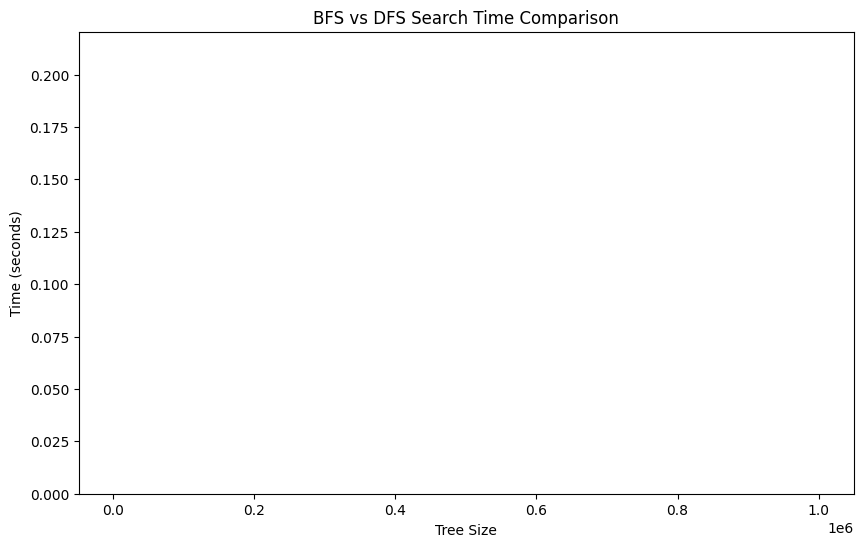

In [10]:
plt.figure(figsize=(10,6))

plt.bar(df["Tree Size"], df["BFS Time (seconds)"], width=0.4, label="BFS", align="center")
plt.bar(df["Tree Size"], df["DFS Time (seconds)"], width=0.4, label="DFS", align="edge")

plt.xlabel("Tree Size")
plt.ylabel("Time (seconds)")
plt.title("BFS vs DFS Search Time Comparison")
plt

# **STEP 8 : Conclusion**

***From the graph and table, it is observed that BFS generally takes more time as the tree size increases due to its level-wise traversal and higher memory overhead. DFS performs relatively faster as it explores depth-first paths and reaches the goal earlier depending on node placement.***